<a href="https://colab.research.google.com/github/monicayar/lab-3/blob/main/lab_3_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Create requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("matplotlib\n")
    f.write("scikit-learn\n")
    f.write("torch\n")

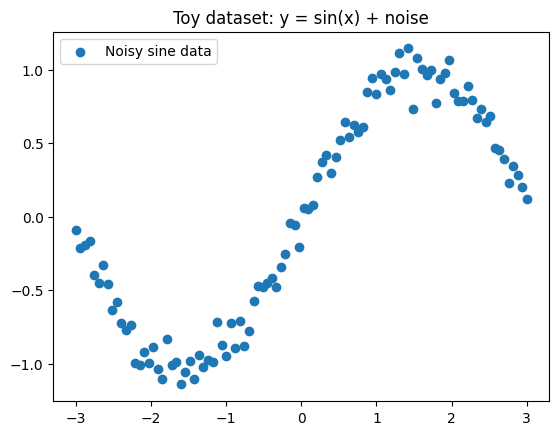

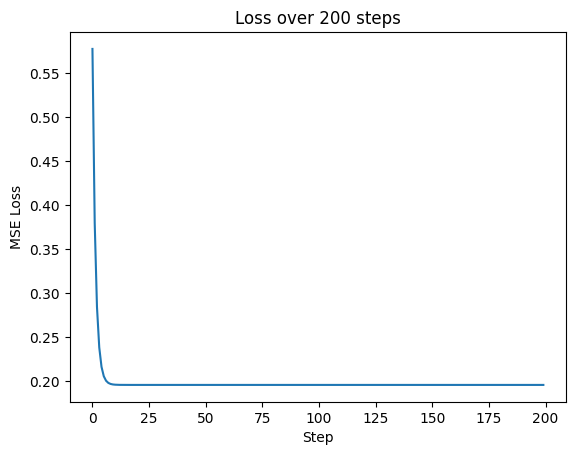

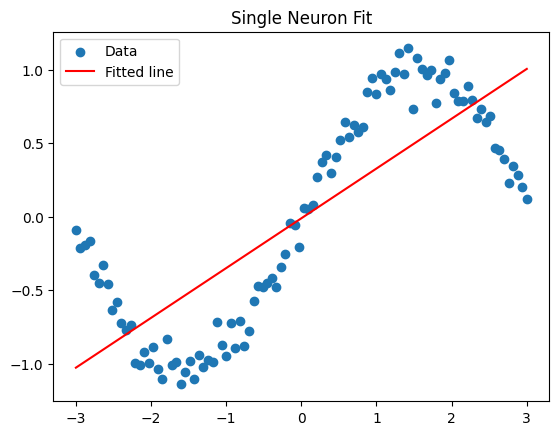

In [20]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, label="Noisy sine data")
plt.title("Toy dataset: y = sin(x) + noise")
plt.legend()
plt.show()

#  Initialise parameters
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.05
losses = []

#  Gradient descent loop
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 200 steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

#  Plot fitted line
plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.title("Single Neuron Fit")
plt.legend()
plt.show()


Student Reasoning :The single neuron

Derive dLoss/dw
The loss function is the Mean Squared Error (MSE):

[ L = \frac{1}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i)^2 ]

where (y_{\hat{i}} = w \cdot x_i + b).

Taking the derivative with respect to (w):

[ \frac{dL}{dw} = \frac{2}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i) \cdot x_i ]

This matches the code implementation:

python dw = np.mean(2 * (y_hat - y) * x)

Underfitting vs Overfitting

The only thing that the neuron can produce is a straight line.

The sine wave is a curved wave that oscillates up and down.

Regardless of the amount of training, one line will never bend to follow the sine.

Therefore, the model is underfitting. It is easier (low capacity) to capture the complexity of the sine wave. Overfitting would imply that the model would learn too much noise, but here the opposite is the issue, i.e., the model is not flexible enough.

Student Reasoning : Hidden layers and activations

A single neuron is only a line.
Adding a hidden layer with nonlinear activation (like tanh) lets the network bend and approximate curves.
Forward pass: (z_1 = xW_1 + b_1), (h = \tanh(z_1)), (y_{\hat} = hW_2 + b_2).
Backward pass uses chain rule: gradients flow from output back through tanh into the input.
Conclusion: depth + activation = flexibility to fit sine wave.


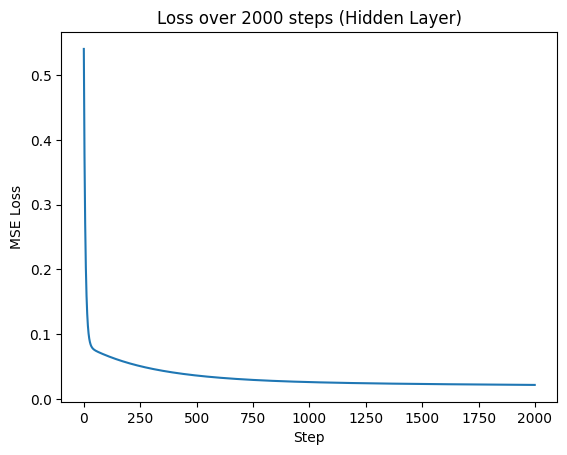

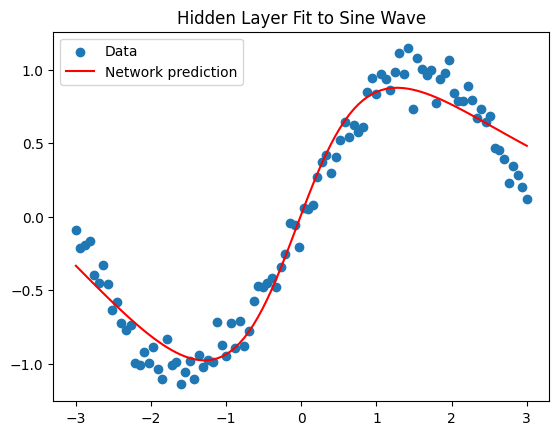

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)   # shape (100,1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # shape (100,1)

# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5   # (1,8)
b1 = np.random.randn(8) * 0.5      # (8,)
W2 = np.random.randn(8, 1) * 0.5   # (8,1)
b2 = np.random.randn(1) * 0.5      # (1,)
lr = 0.01
losses = []

#  Training loop
for step in range(2000):
    # Forward pass
    z1 = x @ W1 + b1        # (100,8)
    h = np.tanh(z1)         # (100,8)
    y_hat = h @ W2 + b2     # (100,1)
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)   # (100,1)
    dW2 = h.T @ d_yhat                  # (8,1)
    db2 = d_yhat.sum(axis=0)            # (1,)
    dh = d_yhat @ W2.T                  # (100,8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)   # (100,8)
    dW1 = x.T @ dz1                     # (1,8)
    db1 = dz1.sum(axis=0)               # (8,)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 2000 steps (Hidden Layer)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot fitted curve
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Network prediction")
plt.title("Hidden Layer Fit to Sine Wave")
plt.legend()
plt.show()


 Student Reasoning :Hidden layers and activations

Why depth helps
A single neuron (just a line) cannot capture curved patterns like sine.
Adding a hidden layer with nonlinear activation (tanh) allows the network to bend and approximate complex shapes.
This shows how depth and activation functions increase model flexibility.
Forward pass
Input goes into hidden layer:
[ z_1 = xW_1 + b_1 ]

Apply activation:
[ h = \tanh(z_1) ]

Hidden output goes to final neuron:
[ y_{\hat} = hW_2 + b_2 ]

Loss is Mean Squared Error (MSE):
[ L = \frac{1}{n}\sum (y_{\hat} - y)^2 ]

Backward pass (chain rule)
Gradient at output:
[ d_{y_{\hat}} = \frac{2}{n}(y_{\hat} - y) ]

Second layer gradients:
[ dW_2 = h^T d_{y_{\hat}}, \quad db_2 = \sum d_{y_{\hat}} ]

Backprop into hidden layer:
[ dh = d_{y_{\hat}} W_2^T ]

Derivative of tanh:
[ dz_1 = dh \cdot (1 - \tanh(z_1)^2) ]

First layer gradients:
[ dW_1 = x^T dz_1, \quad db_1 = \sum dz_1 ]

Conclusion
With hidden neurons and nonlinear activation, the network can bend to follow the sine curve.
This demonstrates why depth + activation functions are essential: they let neural networks learn complex patterns that a single straight line cannot.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1399/3733651798.py:27: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1399/3733651798.py:34: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_1399/3733651798.py:35: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


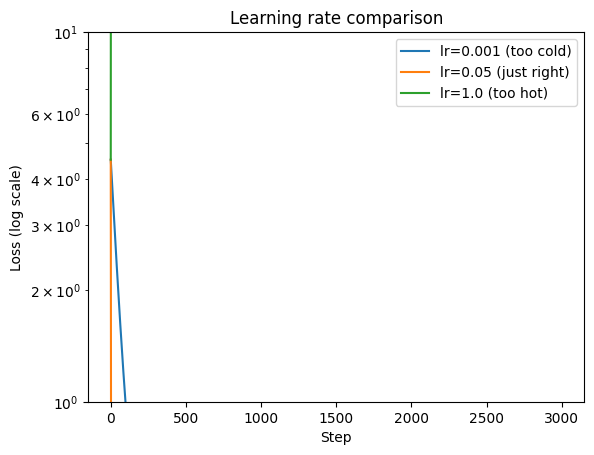

In [22]:
#part 1.3
import numpy as np
import matplotlib.pyplot as plt

# Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Training function
def train_toy(lr, steps=3000):
    np.random.seed(42)  # reset seed for fair comparison

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

#  Run with three learning rates
losses_small = train_toy(lr=0.001)
losses_medium = train_toy(lr=0.05)
losses_large = train_toy(lr=1.0)

#  Plot curves
plt.plot(losses_small, label="lr=0.001 (too cold)")
plt.plot(losses_medium, label="lr=0.05 (just right)")
plt.plot(losses_large, label="lr=1.0 (too hot)")
plt.yscale("log")   # log scale helps
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Learning rate comparison")
plt.legend()
plt.show()



Student Reasoning : Learning rate

lr = 0.001 (too cold):
The loss decreases very slowly. The curve goes down, but progress is tiny. Training takes a long time to reach a good fit.

lr = 0.05 (just right):
The loss decreases smoothly and quickly. The curve goes down steadily without exploding. This is the balanced regime where learning is effective.

lr = 1.0 (too hot):
The loss does not settle. It jumps up and down or even explodes.
A too-large learning rate overshoots the minimum each step, so instead of converging, the model oscillates or diverges.

Conclusion:
The learning rate controls the step size in gradient descent.

Too small → very slow learning.
Just right → efficient convergence.
Too large → unstable training, loss explodes or oscillates.

In [23]:
#part 2.1
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42

# Step 1: Load the dataset (correct link)
OBESITY_URL = "https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/refs/heads/main/Lab2/Obesity_level_prediction_dataset%20(2).csv"
df = pd.read_csv(OBESITY_URL)

print("Dataset loaded. Shape:", df.shape)
print(df.head())

# Step 2: Encode categoricals
# Binary yes/no -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Gender, MTRANS, CAEC, CALC -> LabelEncoder
for col in ["Gender", "MTRANS", "CAEC", "CALC"]:
    df[col] = LabelEncoder().fit_transform(df[col])

# Step 3: Encode target (NObeyesdad) into integers 0..6
y = LabelEncoder().fit_transform(df["NObeyesdad"])
X = df.drop("NObeyesdad", axis=1).values

# Step 4: Stratified train/val/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# Step 5: Scale features (fit only on training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 6: Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Step 7: Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


# Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Dataset loaded. Shape: (2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight 

Student Reasoning : Preprocessing for neural networks

Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

PyTorch’s CrossEntropyLoss combines LogSoftmax and NLLLoss in one function.
It expects the target labels as integers (0, 1, 2, …, 6 for the 7 obesity classes).
Each integer points to the correct class index.
If you gave one-hot vectors, the loss function would not know which index to use, so training would fail.
Why do neural networks care so much about feature scaling, while random forests did not?

Random forests split data by thresholds, so the scale of features does not matter.
Neural networks use gradient descent. The gradient formulas (like dw = 2 * (y_hat - y) * x) depend directly on the size of x.
If features are on very different scales, some gradients become huge and others tiny.
This makes training unstable or very slow. Scaling ensures all features contribute fairly and gradients stay balanced.
What does shuffle=True on the training DataLoader do, and why does it help?

It randomizes the order of training samples in each epoch.
This prevents the model from seeing data in the same fixed order every time.
Shuffling helps break patterns, reduces bias, and improves generalization.
Without shuffling, the network might learn order-specific artifacts instead of the true relationships in the data.

In [24]:
import torch
import torch.nn as nn

# Step 1: Define the FeedForwardNet class
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])   # input -> first hidden
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])  # hidden1 -> hidden2
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)   # hidden2 -> output
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        logits = self.fc3(x)   # raw scores (logits), no softmax
        return logits

# Step 2: Instantiate model
input_dim = X_train.shape[1]   # number of features after preprocessing
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)

# Step 3: Move to device (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# Step 4: Print model
print(model)

# Step 5: Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params)

# Verify first layer count by hand: input_dim * 64 + 64
print("First layer params (manual check):", input_dim * 64 + 64)


FeedForwardNet(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 3399
First layer params (manual check): 1088


Student Reasoning: Architecture

By-hand parameter count for every layer

First layer (input → 64 hidden units): Parameters = input_dim × 64 (weights) + 64 (biases).
Example: if input_dim = 16 → 16 × 64 + 64 = 1088.
Second layer (64 → 32 hidden units):
Parameters = 64 × 32 + 32 = 2080.
Output layer (32 → 7 classes): Parameters = 32 × 7 + 7 = 231.
Total: Add them up and confirm it matches PyTorch’s count from sum(p.numel() for p in model.parameters() if p.requires_grad).
Why ReLU instead of tanh here?

ReLU is simpler and avoids the vanishing gradient problem that tanh often suffers from.
It keeps gradients alive for large positive values, which helps deeper networks train faster and more reliably.
Advantage: ReLU is computationally cheaper and usually leads to faster convergence.
What if we removed the ReLUs?

Without nonlinear activations, the network becomes just a stack of linear transformations.
A composition of linear layers is still linear, so the model could only learn straight-line boundaries.
This means it would collapse to a single linear classifier, unable to capture complex patterns exactly what you proved in Part 1.2.